In [4]:
import os #To work with files and folders
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
from IPython.display import Audio

In [5]:
dataset_path = r"E:\Machine Learning Course\Practicle\06_Speech_Emotion_Recognition\Emotion_Recognizatio_Set"

In [6]:
print(os.listdir(dataset_path)[:5])

['Actor_01', 'Actor_02', 'Actor_03', 'Actor_04', 'Actor_05']


In [7]:
# We are taking only 4 emotions

In [11]:
emotion_map = {
    "01": "neutral",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "08": "Surprised"
}

In [12]:
audio_files = []
labels = []

for actor in os.listdir(dataset_path):
    actor_path = os.path.join(dataset_path, actor)

    if os.path.isdir(actor_path) and actor.startswith("Actor_"):
        for file in os.listdir(actor_path):

            if file.endswith(".wav"):
                parts = file.split("-")

                emotion_code = parts[2]

                if emotion_code in emotion_map:
                    audio_files.append(os.path.join(actor_path, file))
                    labels.append(emotion_map[emotion_code])

In [13]:
print("Total selected files:", len(audio_files))
print(labels[:10])

Total selected files: 864
['neutral', 'neutral', 'neutral', 'neutral', 'happy', 'happy', 'happy', 'happy', 'happy', 'happy']


In [16]:
from collections import Counter

count_df = pd.DataFrame(
    emotion_counts.items(),
    columns=["Emotion", "Count"]
)

count_df

,Emotion,Count
0,neutral,96
1,happy,192
2,sad,192
3,angry,192
4,Surprised,192


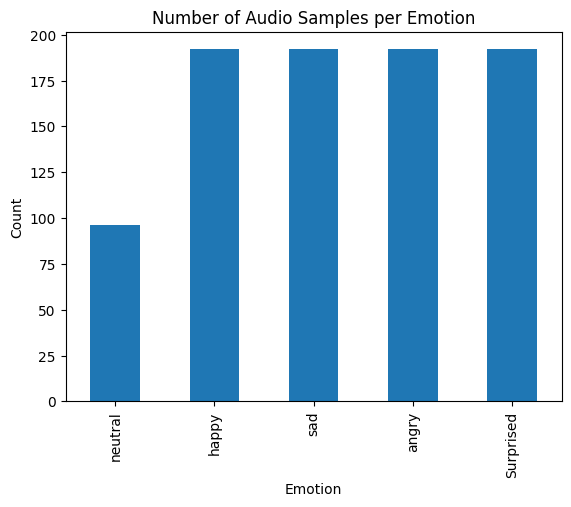

In [17]:
count_df.plot(
    x="Emotion",
    y="Count",
    kind="bar",
    legend=False
)

plt.title("Number of Audio Samples per Emotion")
plt.ylabel("Count")
plt.show()

In [20]:
sample_file = audio_files[320]
print("Label:", labels[320])

Audio(sample_file)

Label: Surprised


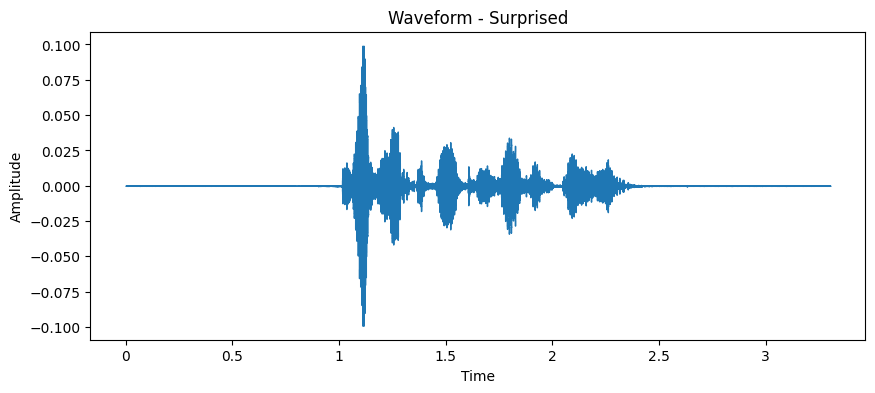

In [23]:
y, sr = librosa.load(sample_file, sr=None)

plt.figure(figsize=(10, 4))
librosa.display.waveshow(y, sr=sr)
plt.title(f"Waveform - {labels[320]}")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

# Librosa ---> features Extraction

In [28]:
def extract_features(file_path):

    y, sr = librosa.load(file_path, sr=None)

    # MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc_mean = np.mean(mfcc, axis=1)

    # Chroma
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma_mean = np.mean(chroma, axis=1)

    # RMS Energy
    rms = librosa.feature.rms(y=y)
    rms_mean = np.mean(rms)

    # Zero Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(y)
    zcr_mean = np.mean(zcr)

    features = np.hstack([
        mfcc_mean,
        chroma_mean,
        rms_mean,
        zcr_mean
    ])

    return features

#MFCC → voice/tone  pattern
#Chroma → pitch-related information
#RMS Energy → how much voice strong/loud?
#Zero Crossing Rate → how rapidly signal is changing

In [29]:
sample_features = extract_features(sample_file)

print(sample_features)
print("Number of features:", len(sample_features))

[-6.56887268e+02  6.06427307e+01  5.70210361e+00  1.06480074e+01
  8.58075809e+00  1.01746674e+01 -4.10237789e+00 -4.23054755e-01
 -2.01112556e+00 -2.12654877e+00 -8.85784328e-01 -2.11940527e+00
 -3.64435482e+00  5.59683204e-01  5.79207122e-01  5.80480874e-01
  6.03037357e-01  6.43252492e-01  6.54696286e-01  6.79780543e-01
  6.33953393e-01  5.82870305e-01  5.64349174e-01  5.99461854e-01
  5.77609181e-01  2.47664028e-03  6.49618826e-02]
Number of features: 27


# Making the Data Frame

In [30]:
all_features = []

for file_path, label in zip(audio_files, labels):
    features = extract_features(file_path)
    all_features.append(list(features) + [label])

columns = (
    [f"MFCC_{i+1}" for i in range(13)] +
    [f"Chroma_{i+1}" for i in range(12)] +
    ["RMS", "ZCR", "Emotion"]
)

df = pd.DataFrame(all_features, columns=columns)

df.head()

,MFCC_1,MFCC_2,MFCC_3,MFCC_4,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,...,Chroma_6,Chroma_7,Chroma_8,Chroma_9,Chroma_10,Chroma_11,Chroma_12,RMS,ZCR,Emotion
0,-726.217224,68.541420,3.293398,12.205300,5.510278,13.667408,-2.983828,3.098029,-3.310813,-1.564384,...,0.617627,0.630300,0.641174,0.643986,0.623945,0.633900,0.629672,0.002120,0.050476,neutral
1,-719.128296,70.201569,1.168397,13.122543,7.836950,14.411290,-4.111360,4.468973,-3.539367,-3.658607,...,0.629304,0.598250,0.602427,0.638104,0.650110,0.663277,0.638956,0.002258,0.052904,neutral
2,-714.995728,69.689346,3.924564,11.924190,6.421723,11.011614,-2.878103,4.509558,-4.476109,-2.671549,...,0.595411,0.606914,0.611433,0.634772,0.586808,0.578905,0.612411,0.002707,0.046627,neutral
3,-710.975281,67.564880,5.782240,13.230727,6.190845,12.628252,-1.675169,5.657494,-4.950634,-3.477545,...,0.646860,0.619975,0.611885,0.633945,0.597960,0.602110,0.619935,0.002521,0.053835,neutral
4,-679.538757,78.698463,0.667738,10.390019,5.207020,11.525229,-7.043530,2.034919,-6.769452,-3.452317,...,0.633900,0.584834,0.557330,0.541521,0.532564,0.563721,0.597406,0.004056,0.055702,happy


In [31]:
print(df.shape)
df["Emotion"].value_counts()

(864, 28)


Emotion
happy        192
angry        192
sad          192
Surprised    192
neutral       96
Name: count, dtype: int64

In [32]:
git add "06_Speech_Emotion_Recognition/Speech_Emotion_Recognition.ipynb"
git commit -m "Create RAVDESS feature dataset with Librosa"
git push

SyntaxError: invalid syntax (1989441830.py, line 1)